# DS Day 01 — Food Delivery: Why Are Orders Getting Delayed?

This notebook performs the complete analysis requested in the challenge:
- Data cleaning and validation
- Exploratory data analysis and descriptive statistics
- 4 visualizations
- Average delivery time by restaurant and area
- Preparation vs delivery-delay analysis
- Distance contribution analysis
- Restaurant/peak-hour operational analysis
- Random Forest prediction model
- Model evaluation
- 5–7 key insights and a practical action plan

**Expected input file:** `food_delivery.csv`


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


## 1. Load the dataset

### Uploading `food_delivery.csv`

If you encounter a `FileNotFoundError`, please upload the `food_delivery.csv` file using the file upload icon on the left sidebar (folder icon) or by dragging and dropping the file into the Colab file explorer.

In [13]:
import os

file_path = 'food_delivery.csv'
if os.path.exists(file_path):
    print(f'The file {file_path} exists in the current directory.')
else:
    print(f'The file {file_path} does NOT exist in the current directory. Please upload it as instructed above.')

The file food_delivery.csv exists in the current directory.


In [14]:
# Change this filename if your CSV has a different name.
df = pd.read_csv('/content/food_delivery.csv')

print('Shape:', df.shape)
display(df.head())

Shape: (1000, 11)


,Order_ID,Restaurant,Area,Distance_KM,Preparation_Time,Delivery_Time,Traffic,Weather,Rider_ID,Order_Time,Peak_Hour
0,ORD00001,Pizza Corner,Saibaba Colony,1.40,25,49,High,Clear,R003,2026-08-11 20:14:00,Yes
1,ORD00002,Fresh Bowl,Peelamedu,2.17,20,58,High,Clear,R049,2026-08-12 09:23:00,No
2,ORD00003,Grill Nation,RS Puram,1.11,30,54,High,Clear,R053,2026-08-20 19:54:00,Yes
3,ORD00004,Annapoorna,Saibaba Colony,5.57,17,48,Low,Clear,R004,2026-08-28 19:46:00,Yes
4,ORD00005,Annapoorna,Singanallur,3.49,24,59,Medium,Rainy,R080,2026-08-04 13:41:00,Yes


## 2. Clean and validate the data

In [15]:
required_cols = [
    'Order_ID', 'Restaurant', 'Area', 'Distance_KM',
    'Preparation_Time', 'Delivery_Time', 'Traffic',
    'Weather', 'Rider_ID', 'Order_Time', 'Peak_Hour'
]

missing_cols = [c for c in required_cols if c not in df.columns]
print('Missing required columns:', missing_cols)

print('\nData types:')
display(df.dtypes)

print('\nMissing values:')
display(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

# Convert numeric columns
numeric_cols = ['Distance_KM', 'Preparation_Time', 'Delivery_Time']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean categorical/text columns
categorical_cols = ['Restaurant', 'Area', 'Traffic', 'Weather', 'Rider_ID']
for col in categorical_cols:
    df[col] = df[col].astype('string').str.strip()

# Parse order time if possible
df['Order_Time'] = pd.to_datetime(df['Order_Time'], errors='coerce')

# Remove impossible numeric values
for col in numeric_cols:
    df.loc[df[col] < 0, col] = np.nan

# Fill numeric missing values with median and categorical missing values with mode
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].notna().any():
        df[col] = df[col].fillna(df[col].mode().iloc[0])

df['Peak_Hour'] = df['Peak_Hour'].astype('string').str.strip().str.lower()

print('Cleaned shape:', df.shape)
display(df.head())


Missing required columns: []

Data types:


,0
Order_ID,object
Restaurant,object
Area,object
Distance_KM,float64
Preparation_Time,int64
Delivery_Time,int64
Traffic,object
Weather,object
Rider_ID,object
Order_Time,object



Missing values:


,0
Order_ID,0
Restaurant,0
Area,0
Distance_KM,0
Preparation_Time,0
Delivery_Time,0
Traffic,0
Weather,0
Rider_ID,0
Order_Time,0



Duplicate rows: 0
Cleaned shape: (1000, 11)


,Order_ID,Restaurant,Area,Distance_KM,Preparation_Time,Delivery_Time,Traffic,Weather,Rider_ID,Order_Time,Peak_Hour
0,ORD00001,Pizza Corner,Saibaba Colony,1.40,25.0,49.0,High,Clear,R003,2026-08-11 20:14:00,yes
1,ORD00002,Fresh Bowl,Peelamedu,2.17,20.0,58.0,High,Clear,R049,2026-08-12 09:23:00,no
2,ORD00003,Grill Nation,RS Puram,1.11,30.0,54.0,High,Clear,R053,2026-08-20 19:54:00,yes
3,ORD00004,Annapoorna,Saibaba Colony,5.57,17.0,48.0,Low,Clear,R004,2026-08-28 19:46:00,yes
4,ORD00005,Annapoorna,Singanallur,3.49,24.0,59.0,Medium,Rainy,R080,2026-08-04 13:41:00,yes


## 3. Descriptive statistics

These statistics help identify the typical order distance, preparation time and delivery time.

In [16]:
display(df[numeric_cols].describe().round(2))

print('Traffic distribution:')
display(df['Traffic'].value_counts(dropna=False))

print('Weather distribution:')
display(df['Weather'].value_counts(dropna=False))

print('Peak-hour distribution:')
display(df['Peak_Hour'].value_counts(dropna=False))


,Distance_KM,Preparation_Time,Delivery_Time
count,1000.00,1000.00,1000.00
mean,3.52,19.31,48.64
std,2.25,6.09,11.84
min,0.80,7.00,17.00
25%,1.92,15.00,40.00
50%,3.04,19.00,48.00
75%,4.55,23.00,56.00
max,12.00,37.00,92.00


Traffic distribution:


,count
Traffic,
Medium,375
Low,354
High,271


Weather distribution:


,count
Weather,
Clear,666
Cloudy,231
Rainy,103


Peak-hour distribution:


,count
Peak_Hour,
no,594
yes,406


## 4. Average delivery time by restaurant and area

In [17]:
restaurant_avg = (
    df.groupby('Restaurant', as_index=False)['Delivery_Time']
      .agg(['mean', 'median', 'count'])
      .sort_values('mean', ascending=False)
)
display(restaurant_avg.round(2))

area_avg = (
    df.groupby('Area', as_index=False)['Delivery_Time']
      .agg(['mean', 'median', 'count'])
      .sort_values('mean', ascending=False)
)
display(area_avg.round(2))


,Restaurant,mean,median,count
7,Grill Nation,55.68,56.0,110
1,Biryani House,54.13,53.0,93
8,Pizza Corner,52.37,52.0,104
5,Food Street,50.14,49.5,100
9,Spice Hub,48.89,48.0,104
4,Dosa Palace,47.24,46.0,95
6,Fresh Bowl,45.78,45.0,94
0,Annapoorna,44.15,44.0,111
2,Burger Point,43.78,44.0,93
3,Cafe Aroma,43.45,42.0,96


,Area,mean,median,count
2,Peelamedu,50.68,50.0,87
1,Kuniyamuthur,49.39,48.0,108
7,Town Hall,49.35,49.0,124
0,Gandhipuram,49.23,48.0,87
9,Vadavalli,48.81,47.0,105
4,Race Course,48.69,48.5,94
3,RS Puram,48.64,48.0,107
5,Saibaba Colony,47.33,46.0,107
6,Singanallur,47.20,46.0,98
8,Ukkadam,46.94,48.0,83


## 5. Visualization 1 — Delivery-time distribution

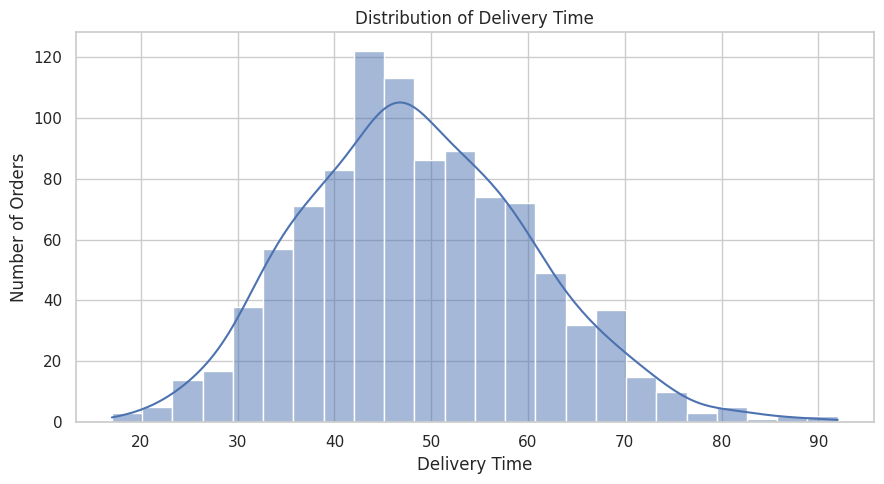

In [18]:
plt.figure(figsize=(9, 5))
sns.histplot(df['Delivery_Time'], kde=True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


## 6. Visualization 2 — Average delivery time by traffic

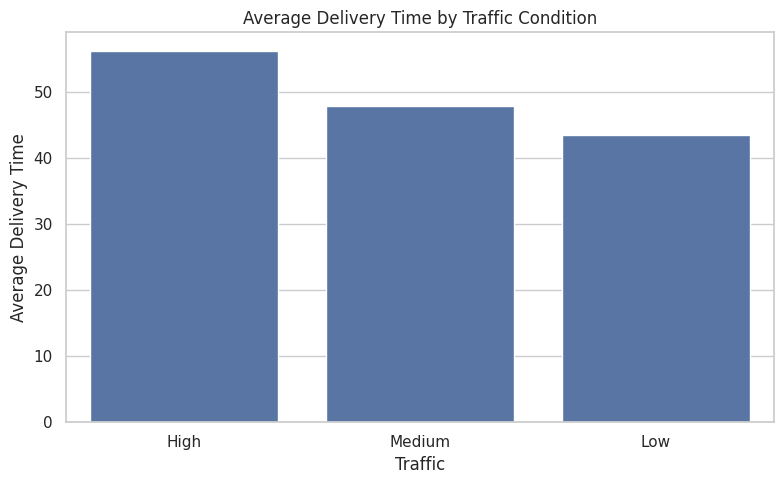

In [19]:
traffic_avg = df.groupby('Traffic', as_index=False)['Delivery_Time'].mean().sort_values('Delivery_Time', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=traffic_avg, x='Traffic', y='Delivery_Time')
plt.title('Average Delivery Time by Traffic Condition')
plt.xlabel('Traffic')
plt.ylabel('Average Delivery Time')
plt.tight_layout()
plt.show()


## 7. Visualization 3 — Distance vs delivery time

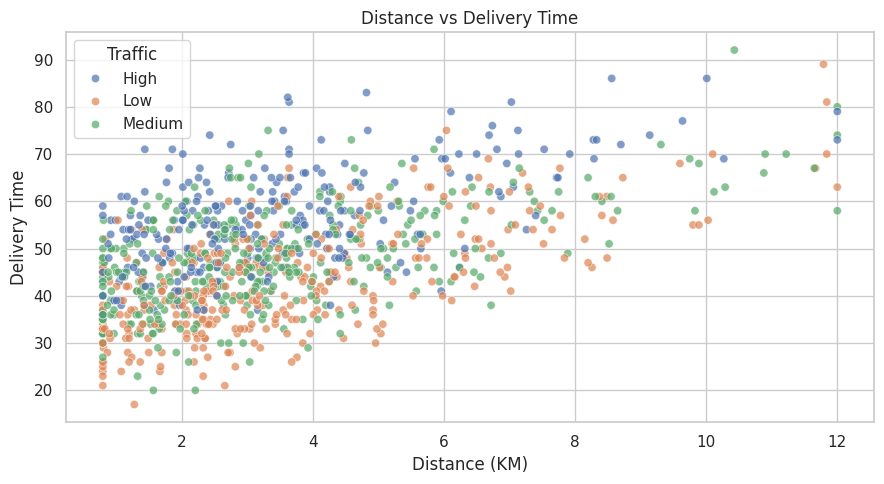

In [20]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Distance_KM', y='Delivery_Time', hue='Traffic', alpha=0.7)
plt.title('Distance vs Delivery Time')
plt.xlabel('Distance (KM)')
plt.ylabel('Delivery Time')
plt.tight_layout()
plt.show()


## 8. Visualization 4 — Preparation time vs delivery time

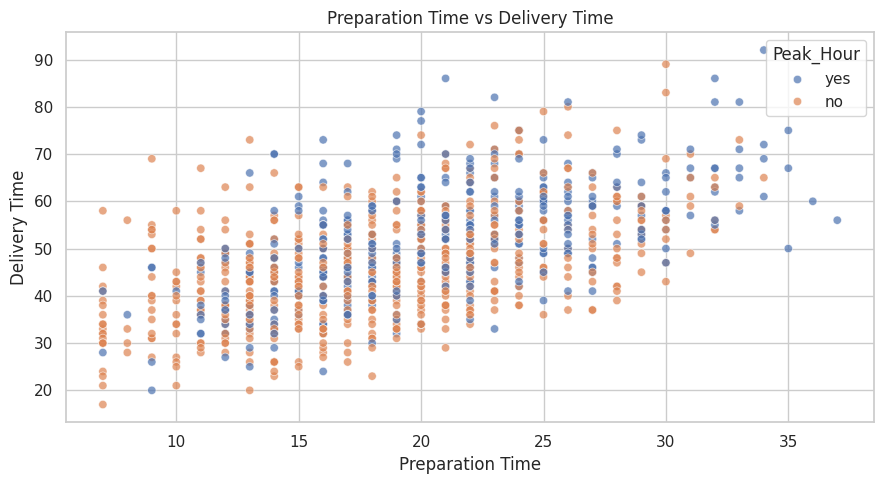

In [21]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Preparation_Time', y='Delivery_Time', hue='Peak_Hour', alpha=0.7)
plt.title('Preparation Time vs Delivery Time')
plt.xlabel('Preparation Time')
plt.ylabel('Delivery Time')
plt.tight_layout()
plt.show()


## 9. Separate restaurant preparation delay from delivery delay

**Assumption:** `Delivery_Time` represents the end-to-end order time and includes preparation. Under this assumption:

`Delivery_Delay = Delivery_Time - Preparation_Time`

If your dataset defines `Delivery_Time` as delivery-only time after preparation, do **not** subtract preparation time; instead use the delivery-time column directly.

In [22]:
df['Delivery_Delay'] = (df['Delivery_Time'] - df['Preparation_Time']).clip(lower=0)

delay_summary = pd.DataFrame({
    'Average Preparation Time': [df['Preparation_Time'].mean()],
    'Average Delivery Delay': [df['Delivery_Delay'].mean()],
    'Average Total Delivery Time': [df['Delivery_Time'].mean()]
})

display(delay_summary.round(2))

restaurant_delay = (
    df.groupby('Restaurant')
      .agg(Avg_Preparation=('Preparation_Time', 'mean'),
           Avg_Delivery_Delay=('Delivery_Delay', 'mean'),
           Avg_Total_Time=('Delivery_Time', 'mean'),
           Orders=('Order_ID', 'count'))
      .sort_values('Avg_Total_Time', ascending=False)
)
display(restaurant_delay.round(2))


,Average Preparation Time,Average Delivery Delay,Average Total Delivery Time
0,19.31,29.32,48.64


,Avg_Preparation,Avg_Delivery_Delay,Avg_Total_Time,Orders
Restaurant,,,,
Grill Nation,26.15,29.54,55.68,110
Biryani House,25.02,29.11,54.13,93
Pizza Corner,23.67,28.69,52.37,104
Food Street,21.36,28.78,50.14,100
Spice Hub,19.37,29.53,48.89,104
Dosa Palace,17.79,29.45,47.24,95
Fresh Bowl,15.53,30.24,45.78,94
Annapoorna,15.76,28.40,44.15,111
Burger Point,13.99,29.80,43.78,93


## 10. Is distance the biggest contributor?

Correlation is a first diagnostic, not proof of causation. We compare distance with preparation time and create a correlation matrix.

In [23]:
corr_cols = ['Distance_KM', 'Preparation_Time', 'Delivery_Time', 'Delivery_Delay']
corr = df[corr_cols].corr().round(3)
display(corr)

print('Absolute correlation with Delivery_Time:')
corr_target = corr['Delivery_Time'].drop('Delivery_Time').abs().sort_values(ascending=False)
display(corr_target)


,Distance_KM,Preparation_Time,Delivery_Time,Delivery_Delay
Distance_KM,1.000,-0.041,0.532,0.665
Preparation_Time,-0.041,1.000,0.557,0.052
Delivery_Time,0.532,0.557,1.000,0.858
Delivery_Delay,0.665,0.052,0.858,1.000


Absolute correlation with Delivery_Time:


,Delivery_Time
Delivery_Delay,0.858
Preparation_Time,0.557
Distance_KM,0.532


## 11. Identify operational problem areas

The tables below identify restaurants and peak-hour groups with higher-than-average delivery times.

In [24]:
overall_avg = df['Delivery_Time'].mean()

restaurant_problems = (
    df.groupby('Restaurant')
      .agg(Avg_Delivery_Time=('Delivery_Time', 'mean'), Orders=('Order_ID', 'count'))
      .query('Orders >= 3')
      .sort_values('Avg_Delivery_Time', ascending=False)
)
restaurant_problems['Above_Overall_Avg'] = restaurant_problems['Avg_Delivery_Time'] > overall_avg
display(restaurant_problems.round(2))

peak_problems = (
    df.groupby('Peak_Hour')
      .agg(Avg_Delivery_Time=('Delivery_Time', 'mean'),
           Avg_Distance=('Distance_KM', 'mean'),
           Avg_Preparation=('Preparation_Time', 'mean'),
           Orders=('Order_ID', 'count'))
      .sort_values('Avg_Delivery_Time', ascending=False)
)
display(peak_problems.round(2))

restaurant_peak = (
    df.groupby(['Restaurant', 'Peak_Hour'])
      .agg(Avg_Delivery_Time=('Delivery_Time', 'mean'), Orders=('Order_ID', 'count'))
      .query('Orders >= 2')
      .sort_values('Avg_Delivery_Time', ascending=False)
)
display(restaurant_peak.head(15).round(2))


,Avg_Delivery_Time,Orders,Above_Overall_Avg
Restaurant,,,
Grill Nation,55.68,110,True
Biryani House,54.13,93,True
Pizza Corner,52.37,104,True
Food Street,50.14,100,True
Spice Hub,48.89,104,True
Dosa Palace,47.24,95,False
Fresh Bowl,45.78,94,False
Annapoorna,44.15,111,False
Burger Point,43.78,93,False


,Avg_Delivery_Time,Avg_Distance,Avg_Preparation,Orders
Peak_Hour,,,,
yes,52.01,3.48,20.72,406
no,46.33,3.55,18.36,594


,,Avg_Delivery_Time,Orders
Restaurant,Peak_Hour,,
Grill Nation,yes,59.13,46
Biryani House,yes,59.10,30
Pizza Corner,yes,56.61,33
Food Street,yes,54.20,46
Spice Hub,yes,53.79,43
Grill Nation,no,53.20,64
Biryani House,no,51.76,63
Dosa Palace,yes,51.02,41
Pizza Corner,no,50.39,71


## 12. Random Forest model

The prediction target is `Delivery_Time`. Numeric and categorical variables are handled through a preprocessing pipeline.

In [25]:
# Create useful time features when Order_Time is available
df['Order_Hour'] = df['Order_Time'].dt.hour.fillna(-1).astype(int)
df['Order_Day'] = df['Order_Time'].dt.dayofweek.fillna(-1).astype(int)

feature_cols = [
    'Restaurant', 'Area', 'Distance_KM', 'Preparation_Time',
    'Traffic', 'Weather', 'Peak_Hour', 'Order_Hour', 'Order_Day'
]

model_df = df[feature_cols + ['Delivery_Time']].dropna().copy()

X = model_df[feature_cols]
y = model_df['Delivery_Time']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

categorical_features = ['Restaurant', 'Area', 'Traffic', 'Weather', 'Peak_Hour']
numeric_features = ['Distance_KM', 'Preparation_Time', 'Order_Hour', 'Order_Day']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', 'passthrough', numeric_features)
])

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

rf_pipeline.fit(X_train, y_train)
pred = rf_pipeline.predict(X_test)

print('Random Forest model trained successfully.')


Random Forest model trained successfully.


## 13. Model evaluation

In [26]:
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.3f}')

evaluation = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Value': [mae, rmse, r2]
})
display(evaluation.round(3))


MAE  : 4.77
RMSE : 6.03
R²   : 0.737


,Metric,Value
0,MAE,4.767
1,RMSE,6.035
2,R2,0.737


## 14. Feature importance

This shows which model inputs contribute most to the Random Forest predictions. For one-hot encoded categorical variables, multiple encoded columns may represent the same original feature.

In [27]:
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
      .sort_values('Importance', ascending=False)
)

display(feature_importance.head(15).round(4))


,Feature,Importance
29,num__Preparation_Time,0.3476
28,num__Distance_KM,0.3404
20,cat__Traffic_High,0.1021
25,cat__Weather_Rainy,0.0357
21,cat__Traffic_Low,0.0317
30,num__Order_Hour,0.0280
31,num__Order_Day,0.0229
22,cat__Traffic_Medium,0.0116
23,cat__Weather_Clear,0.0077
17,cat__Area_Town Hall,0.0050


## 15. Automatically generate key findings

Run this section after the model and analysis cells. It prints data-driven statements that can be used in the final report.

In [28]:
top_restaurant = restaurant_avg.index[0]
top_restaurant_time = restaurant_avg.iloc[0]['mean']
top_area = area_avg.index[0]
top_area_time = area_avg.iloc[0]['mean']
top_traffic = traffic_avg.iloc[0]['Traffic']
top_traffic_time = traffic_avg.iloc[0]['Delivery_Time']

print('KEY INSIGHTS')
print('-' * 60)
print(f'1. Overall average delivery time: {df["Delivery_Time"].mean():.2f}')
print(f'2. Restaurant with highest average delivery time: {top_restaurant} ({top_restaurant_time:.2f})')
print(f'3. Area with highest average delivery time: {top_area} ({top_area_time:.2f})')
print(f'4. Traffic condition with highest average delivery time: {top_traffic} ({top_traffic_time:.2f})')
print(f'5. Average preparation time: {df["Preparation_Time"].mean():.2f}')
print(f'6. Average delivery-delay component: {df["Delivery_Delay"].mean():.2f}')
print(f'7. Random Forest R²: {r2:.3f}; MAE: {mae:.2f}; RMSE: {rmse:.2f}')

print('\nPRACTICAL ACTION PLAN')
print('1. Investigate restaurants with consistently high average preparation time.')
print('2. Increase rider availability during high-delay peak periods.')
print('3. Monitor high-distance orders and improve delivery-zone assignment.')
print('4. Use traffic/weather information for dynamic ETA estimates.')
print('5. Review restaurant-area combinations with repeated high delivery times.')


KEY INSIGHTS
------------------------------------------------------------
1. Overall average delivery time: 48.64
2. Restaurant with highest average delivery time: 7 (55.68)
3. Area with highest average delivery time: 2 (50.68)
4. Traffic condition with highest average delivery time: High (56.28)
5. Average preparation time: 19.31
6. Average delivery-delay component: 29.32
7. Random Forest R²: 0.737; MAE: 4.77; RMSE: 6.03

PRACTICAL ACTION PLAN
1. Investigate restaurants with consistently high average preparation time.
2. Increase rider availability during high-delay peak periods.
3. Monitor high-distance orders and improve delivery-zone assignment.
4. Use traffic/weather information for dynamic ETA estimates.
5. Review restaurant-area combinations with repeated high delivery times.


## Final submission checklist

- [x] Data cleaning and validation
- [x] Descriptive statistics
- [x] 4 visualizations
- [x] Average delivery time by restaurant and area
- [x] Preparation vs delivery-delay analysis
- [x] Distance contribution analysis
- [x] Restaurant and peak-hour problem identification
- [x] Random Forest model
- [x] MAE, RMSE and R² evaluation
- [x] Feature importance
- [x] 5–7 data-driven insights
- [x] Practical action plan

**Note:** The actual numerical findings will appear only after the real `food_delivery.csv` dataset is loaded. Do not submit invented values when the dataset is not available.